# Norton Equivalent

The American Engineer, E. L. Norton published in 1926 a theorem similar to *Thévenin's Theorem*, which he called *Norton's Theorem* {cite}`alexander2016fundamentals`.

The Norton resistance $R_N$ equals the Thevenin resistance $R_{TH}$, and can be found in the same way.

$$R_N = R_{TH}$$

A linear two terminal circuit in the figure nelow represents a one port (two terminal) network. 

The voltage of the port is $V_{ab} = V_a - V_b$ and the current entering the port is $i_{ab}$
When the terminals are shorted, $V_{ab}=0$ and the resulting current is the short-circuit current

$$i_{sc} = I_N$$

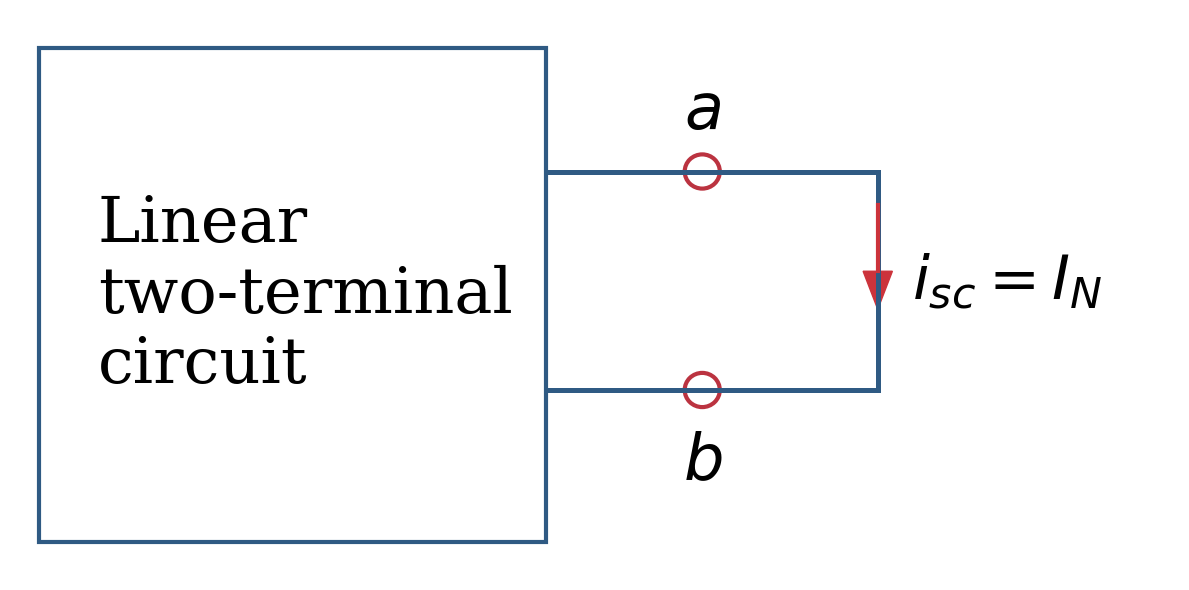

In [1]:
# TEST CELL
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Polygon

fig, ax = plt.subplots(figsize=(12,6))
ax.set_xlim(0,12)
ax.set_ylim(0,6)
ax.axis('off')

# Main linear two-terminal circuit block
ax.add_patch(Rectangle((0.3,0.4), 5.2, 5.2, fill=False, lw=3, ec='#2f5a83'))
ax.text(0.9,3.0,'Linear\ntwo-terminal\ncircuit', fontsize=46,
        va='center', ha='left', family='serif')

# Terminals and short-circuit loop
ax.plot([5.5,7.1],[4.3,4.3], lw=3.6, color='#2f5a83')
ax.plot([5.5,7.1],[2.0,2.0], lw=3.6, color='#2f5a83')
ax.plot([7.1,8.9],[4.3,4.3], lw=3.6, color='#2f5a83')
ax.plot([7.1,8.9],[2.0,2.0], lw=3.6, color='#2f5a83')
ax.plot([8.9,8.9],[2.0,4.3], lw=3.6, color='#2f5a83')

# Terminal circles
ax.add_patch(Circle((7.1,4.3),0.18,fill=True,fc='white',ec='#bb3340',lw=3))
ax.add_patch(Circle((7.1,2.0),0.18,fill=True,fc='white',ec='#bb3340',lw=3))

# Current arrow
arrow = Polygon([[8.75,3.25],[9.05,3.25],[8.9,2.85]], closed=True,
                fc='#cc333b', ec='#cc333b')
ax.add_patch(arrow)
ax.plot([8.9,8.9],[3.95,3.25], lw=3, color='#cc333b')

# Labels
ax.text(7.1,4.75,'$a$', fontsize=46, family='serif', ha='center')
ax.text(7.1,1.05,'$b$', fontsize=46, family='serif', ha='center')
ax.text(9.25,2.95,r'$i_{sc}=I_N$', fontsize=44, family='serif')

plt.tight_layout()
plt.show()


You do not know what is inside.
If we only have access to terminals a and b, the admittance, Y $\big(=\frac{1}{Z}\big)$, can be determined by:
- Apply a voltage V between a and b.
- Measure the current I flowing into the circuit.
  
Compute

$$Y=\frac{I}{V}$$

That ratio is the input admittance or driving-point admittance.

If we already have found the Thévenin equivalent circuit, a Norton equivalent can be found by source transformation.
    
```
Two sources (or circuits in general) 
are said to be equivalent
if they have the same i-v relationship
at a pair of terminals.
```

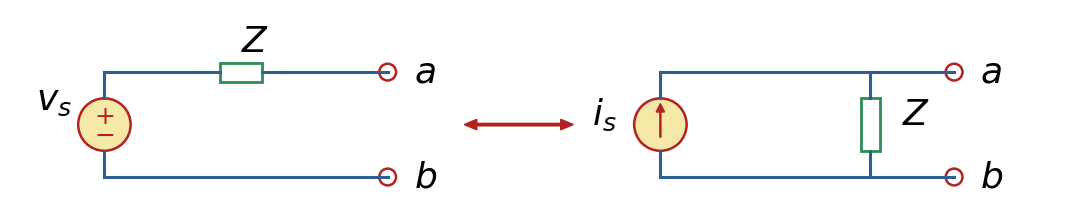

In [3]:
# TEST CELL
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrow
import numpy as np
from matplotlib.patches import Rectangle


def draw_resistor(ax, x1, y1, x2, y2,
                  height=0.18,
                  color='seagreen',
                  wire_color='#2f5f91'):
    """
    Draws a European (IEC) resistor symbol.
    Assumes a horizontal resistor.
    """

    width = x2 - x1
    body_frac = 0.5

    body_w = width * body_frac
    left = (x1 + x2) / 2 - body_w / 2

    # wires
    ax.plot([x1, left], [y1, y1], lw=2.2, color=wire_color)
    ax.plot([left + body_w, x2], [y1, y1], lw=2.2, color=wire_color)

    # resistor body
    rect = Rectangle(
        (left, y1 - height / 2),
        body_w,
        height,
        facecolor='white',
        edgecolor=color,
        lw=2
    )
    ax.add_patch(rect)


def draw_voltage_source(ax, cx, cy, r=0.25):
    circ = Circle((cx, cy), r, facecolor='#f6e9a8', edgecolor='firebrick', lw=1.8)
    ax.add_patch(circ)
    ax.text(cx, cy + 0.08, '+', color='firebrick', fontsize=18, ha='center', va='center')
    ax.text(cx, cy - 0.10, '−', color='firebrick', fontsize=18, ha='center', va='center')


def draw_current_source(ax, cx, cy, r=0.25):
    circ = Circle((cx, cy), r, facecolor='#f6e9a8', edgecolor='firebrick', lw=1.8)
    ax.add_patch(circ)
    ax.arrow(cx, cy - 0.12, 0, 0.24, width=0.01, head_width=0.08, head_length=0.08, color='firebrick')


fig, ax = plt.subplots(figsize=(11, 3))
wire = '#2f5f91'
ytop = 1.0
ybot = 0.0

draw_voltage_source(ax, 0.7, 0.5)
ax.plot([0.7, 0.7], [0.75, ytop], color=wire, lw=2.2)
ax.plot([0.7, 1.6], [ytop, ytop], color=wire, lw=2.2)
draw_resistor(ax, 1.6, ytop, 2.4, ytop)
ax.plot([2.4, 3.4], [ytop, ytop], color=wire, lw=2.2)
ax.plot([0.7, 0.7], [0.25, ybot], color=wire, lw=2.2)
ax.plot([0.7, 3.4], [ybot, ybot], color=wire, lw=2.2)

for x, y in [(3.4, ytop), (3.4, ybot)]:
    ax.add_patch(Circle((x, y), 0.08, facecolor='white', edgecolor='firebrick', lw=1.8))

ax.text(2.0, 1.2, r'$Z$', fontsize=26)
ax.text(3.65, ytop, r'$a$', fontsize=26, va='center')
ax.text(3.65, ybot, r'$b$', fontsize=26, va='center')
ax.text(0.05, 0.65, r'$v_s$', fontsize=26)

ax.add_patch(FancyArrow(4.25, 0.5, 0.8, 0, width=0.02, head_width=0.10, head_length=0.12, color='firebrick'))
ax.add_patch(FancyArrow(5.05, 0.5, -0.8, 0, width=0.02, head_width=0.10, head_length=0.12, color='firebrick'))

# Vertical IEC resistor
xr = 8.0

body_h = 0.50
body_w = 0.18

ax.plot([xr, xr], [ytop, 0.75], color=wire, lw=2.2)

rect = Rectangle(
    (xr - body_w / 2, 0.5 - body_h / 2),
    body_w,
    body_h,
    facecolor='white',
    edgecolor='seagreen',
    lw=2
)
ax.add_patch(rect)

ax.plot([xr, xr], [0.25, ybot], color=wire, lw=2.2)
x0 = 6.0
draw_current_source(ax, x0, 0.5)
ax.plot([x0, x0], [0.75, ytop], color=wire, lw=2.2)
ax.plot([x0, x0], [0.25, ybot], color=wire, lw=2.2)
ax.plot([x0, 8.8], [ytop, ytop], color=wire, lw=2.2)
ax.plot([x0, 8.8], [ybot, ybot], color=wire, lw=2.2)



for x, y in [(8.8, ytop), (8.8, ybot)]:
    ax.add_patch(Circle((x, y), 0.08, facecolor='white', edgecolor='firebrick', lw=1.8))

ax.text(8.3, 0.5, r'$Z$', fontsize=26)
ax.text(9.05, ytop, r'$a$', fontsize=26, va='center')
ax.text(9.05, ybot, r'$b$', fontsize=26, va='center')
ax.text(5.35, 0.5, r'$i_s$', fontsize=26)

ax.set_aspect('equal')
ax.set_xlim(-0.2, 10)
ax.set_ylim(-0.2, 1.6)
ax.axis('off')

plt.tight_layout()
plt.show()
